# Gradient Descent for Linear Regression

This notebook implements gradient descent from scratch and visualizes how the squared-error objective decreases.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
X = np.array([[1.0], [2.0], [3.0], [4.0], [5.0]])
y = np.array([2.2, 3.9, 6.1, 7.8, 10.2])
X_aug = np.c_[np.ones(len(X)), X]
print(f'Training data: {len(X)} observations')


Training data: 5 observations


## Gradient

With `J(theta) = 1/2 sum_i (theta^T x_i - y_i)^2`, the gradient is obtained by differentiating the objective with respect to theta.


In [3]:
def loss(X, y, theta):
    errors = X @ theta - y
    return 0.5 * np.sum(errors ** 2)

def gradient(X, y, theta):
    return X.T @ (X @ theta - y)


## Gradient descent

Each step moves the parameters in the opposite direction of the gradient.


In [4]:
theta = np.zeros(X_aug.shape[1])
learning_rate = 0.01
iterations = 2000
history = []

for _ in range(iterations):
    history.append(loss(X_aug, y, theta))
    theta -= learning_rate * gradient(X_aug, y, theta)

print('Initial objective:', history[0])
print('Final objective:', history[-1])
print('Learned theta:', theta)


Initial objective: 111.07
Final objective: 0.06550000000000031
Learned theta: [0.07000002 1.98999999]


## 1. Objective decreases


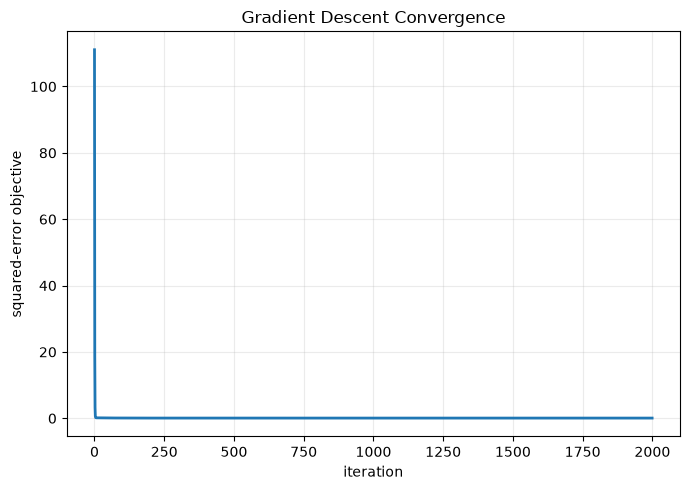

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(history, linewidth=2)
plt.xlabel('iteration')
plt.ylabel('squared-error objective')
plt.title('Gradient Descent Convergence')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## 2. Learned regression line

The five training observations are shown as points, so we can see what the learned model is trying to fit.


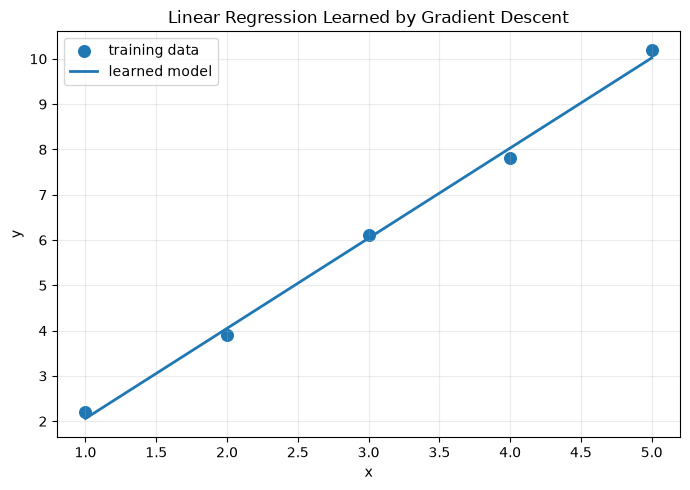

In [7]:
xx = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
yy = np.c_[np.ones(len(xx)), xx] @ theta
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], y, s=70, label='training data')
plt.plot(xx[:, 0], yy, linewidth=2, label='learned model')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Learned by Gradient Descent')
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()
